In [55]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt 
%matplotlib inline

In [56]:
words = open("names.txt", "r").read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [57]:
len(words)

32033

In [58]:
# build the vocabulary characters and mapping to/from integers
chars = sorted(list(set("".join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi["."] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [59]:
# build the dataset 
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y=[],[]
for w in words[:5]:
    print(w)
    context = [0] * block_size
    for ch in w + ".":
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print("".join(itos[i] for i in context), "--->", itos[ix])
        context = context[1:] + [ix] #crop and append  

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [60]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [61]:
C = torch.randn((27,2))
C[5]


tensor([-2.2157,  0.3399])

In [62]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([-2.2157,  0.3399])

In [63]:
C[X].shape

torch.Size([32, 3, 2])

In [64]:
X[13,2]

tensor(1)

In [65]:
C[X][13,2]

tensor([0.7526, 0.8120])

In [66]:
C[1]

tensor([0.7526, 0.8120])

In [67]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [68]:
w1 = torch.randn((6,100))
b1 = torch.randn(100)

In [69]:
# emb @ w1 + b1

In [70]:
torch.cat([emb[:,0,:],emb[:,1,:],emb[:,2,:]],1).shape

torch.Size([32, 6])

In [71]:
torch.unbind(emb,1)

(tensor([[-0.2459,  0.0547],
         [-0.2459,  0.0547],
         [-0.2459,  0.0547],
         [-2.2157,  0.3399],
         [ 0.0311,  1.9640],
         [-0.2459,  0.0547],
         [-0.2459,  0.0547],
         [-0.2459,  0.0547],
         [ 0.7953, -0.7297],
         [ 0.6242,  0.4748],
         [ 0.4652, -2.4095],
         [-2.2368,  0.5116],
         [-0.2459,  0.0547],
         [-0.2459,  0.0547],
         [-0.2459,  0.0547],
         [ 0.7526,  0.8120],
         [-0.2459,  0.0547],
         [-0.2459,  0.0547],
         [-0.2459,  0.0547],
         [ 0.4652, -2.4095],
         [ 0.0403, -1.7021],
         [ 0.7526,  0.8120],
         [ 1.4046,  1.1058],
         [-2.2157,  0.3399],
         [ 0.6242,  0.4748],
         [-0.2459,  0.0547],
         [-0.2459,  0.0547],
         [-0.2459,  0.0547],
         [ 0.0403, -1.7021],
         [ 0.7953, -0.7297],
         [-0.1348, -0.0166],
         [ 0.8151,  0.8698]]),
 tensor([[-0.2459,  0.0547],
         [-0.2459,  0.0547],
         [-2

In [72]:
torch.cat((torch.unbind(emb,1)),1)

tensor([[-0.2459,  0.0547, -0.2459,  0.0547, -0.2459,  0.0547],
        [-0.2459,  0.0547, -0.2459,  0.0547, -2.2157,  0.3399],
        [-0.2459,  0.0547, -2.2157,  0.3399,  0.0311,  1.9640],
        [-2.2157,  0.3399,  0.0311,  1.9640,  0.0311,  1.9640],
        [ 0.0311,  1.9640,  0.0311,  1.9640,  0.7526,  0.8120],
        [-0.2459,  0.0547, -0.2459,  0.0547, -0.2459,  0.0547],
        [-0.2459,  0.0547, -0.2459,  0.0547,  0.7953, -0.7297],
        [-0.2459,  0.0547,  0.7953, -0.7297,  0.6242,  0.4748],
        [ 0.7953, -0.7297,  0.6242,  0.4748,  0.4652, -2.4095],
        [ 0.6242,  0.4748,  0.4652, -2.4095, -2.2368,  0.5116],
        [ 0.4652, -2.4095, -2.2368,  0.5116,  0.4652, -2.4095],
        [-2.2368,  0.5116,  0.4652, -2.4095,  0.7526,  0.8120],
        [-0.2459,  0.0547, -0.2459,  0.0547, -0.2459,  0.0547],
        [-0.2459,  0.0547, -0.2459,  0.0547,  0.7526,  0.8120],
        [-0.2459,  0.0547,  0.7526,  0.8120, -2.2368,  0.5116],
        [ 0.7526,  0.8120, -2.2368,  0.5

In [73]:
torch.cat((torch.unbind(emb,1)),1).shape

torch.Size([32, 6])

In [74]:
a = torch.arange(18)

In [75]:
a.shape

torch.Size([18])

In [76]:
# a.view(9,2)
# a.view(2,9)
a.view(3,3,2)

tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15],
         [16, 17]]])

In [77]:
a.storage

<bound method Tensor.storage of tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])>

In [78]:
emb.shape

torch.Size([32, 3, 2])

In [79]:
emb.view(32,6)

tensor([[-0.2459,  0.0547, -0.2459,  0.0547, -0.2459,  0.0547],
        [-0.2459,  0.0547, -0.2459,  0.0547, -2.2157,  0.3399],
        [-0.2459,  0.0547, -2.2157,  0.3399,  0.0311,  1.9640],
        [-2.2157,  0.3399,  0.0311,  1.9640,  0.0311,  1.9640],
        [ 0.0311,  1.9640,  0.0311,  1.9640,  0.7526,  0.8120],
        [-0.2459,  0.0547, -0.2459,  0.0547, -0.2459,  0.0547],
        [-0.2459,  0.0547, -0.2459,  0.0547,  0.7953, -0.7297],
        [-0.2459,  0.0547,  0.7953, -0.7297,  0.6242,  0.4748],
        [ 0.7953, -0.7297,  0.6242,  0.4748,  0.4652, -2.4095],
        [ 0.6242,  0.4748,  0.4652, -2.4095, -2.2368,  0.5116],
        [ 0.4652, -2.4095, -2.2368,  0.5116,  0.4652, -2.4095],
        [-2.2368,  0.5116,  0.4652, -2.4095,  0.7526,  0.8120],
        [-0.2459,  0.0547, -0.2459,  0.0547, -0.2459,  0.0547],
        [-0.2459,  0.0547, -0.2459,  0.0547,  0.7526,  0.8120],
        [-0.2459,  0.0547,  0.7526,  0.8120, -2.2368,  0.5116],
        [ 0.7526,  0.8120, -2.2368,  0.5

In [80]:
emb.view(32,6) == torch.cat(torch.unbind(emb,1),1)

tensor([[True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, T

In [81]:
# h = emb.view(32,6) @w1+b1 # this creates new memory to avoid use the following 

In [82]:
# h.shape

In [83]:
h = torch.tanh(emb.view(-1,6) @ w1+b1)

In [84]:
h

tensor([[-0.8766, -0.6151,  0.7973,  ...,  0.5867,  0.7289, -0.0055],
        [ 0.7817, -0.4493, -0.4023,  ...,  0.9418, -0.5589,  0.9960],
        [-1.0000, -1.0000,  0.9395,  ...,  0.9917, -0.8985,  0.6793],
        ...,
        [-0.9953, -0.1113,  0.0895,  ...,  0.8373,  0.9771, -0.9826],
        [-0.5692,  0.8746,  0.9307,  ..., -0.9113,  0.9997, -0.8948],
        [-0.5357,  0.7845,  0.5978,  ..., -0.8496, -0.7742, -0.8875]])

In [85]:
h.shape

torch.Size([32, 100])

In [86]:
w2 = torch.randn((100,27))
b2 = torch.randn(27)

In [87]:
logits = h @ w2 + b2

In [88]:
logits.shape

torch.Size([32, 27])

In [89]:
logits

tensor([[ 1.9313e+01,  5.7545e+00,  2.6730e+00, -2.5097e+00,  5.3125e+00,
          4.2783e+00,  3.8250e+00, -7.7069e-01,  6.0825e+00,  8.5391e-01,
          4.2372e-01,  5.4285e+00,  5.0006e+00, -4.7449e+00, -7.1697e+00,
          5.4835e+00,  7.3096e+00, -1.9869e+00, -4.3867e+00, -1.6188e+00,
          8.4661e+00, -1.4321e+00, -8.7229e+00,  1.3434e+01,  3.2115e+00,
         -4.0063e+00, -5.5296e+00],
        [ 7.6723e+00,  5.8880e+00,  1.4623e-01, -2.7480e+00, -3.4432e+00,
          7.9570e+00, -1.2752e+01, -4.4436e+00, -1.0654e+00, -7.1372e+00,
          1.0311e+01, -9.1504e+00,  1.3554e+00, -3.1953e+00, -1.7011e+00,
         -4.8139e-01,  5.4734e-01,  5.5205e+00, -4.8396e+00, -1.6573e+01,
          5.5615e+00, -5.6382e+00, -6.7600e+00,  1.1854e+01,  1.0636e+01,
         -5.3265e-01, -8.4592e+00],
        [ 1.8986e+01, -4.4435e+00,  6.1462e+00,  1.8190e+00,  4.2336e+00,
         -6.1537e+00, -7.8766e+00, -4.4651e+00, -1.5227e+00, -4.5075e+00,
         -2.2839e+00,  8.1904e+00,  1.34

In [90]:
counts = logits.exp()

In [91]:
prob = counts / counts.sum(1, keepdims=True)

In [92]:
prob.shape

torch.Size([32, 27])

In [93]:
prob

tensor([[9.9718e-01, 1.2893e-06, 5.9166e-08, 3.3209e-10, 8.2867e-07, 2.9462e-07,
         1.8723e-07, 1.8902e-09, 1.7897e-06, 9.5953e-09, 6.2407e-09, 9.3061e-07,
         6.0666e-07, 3.5524e-11, 3.1438e-12, 9.8326e-07, 6.1058e-06, 5.6014e-10,
         5.0827e-11, 8.0940e-10, 1.9409e-05, 9.7552e-10, 6.6512e-13, 2.7884e-03,
         1.0138e-07, 7.4356e-11, 1.6208e-11],
        [9.8411e-03, 1.6525e-03, 5.3031e-06, 2.9349e-07, 1.4643e-07, 1.3083e-02,
         1.3274e-11, 5.3849e-08, 1.5789e-06, 3.6422e-09, 1.3779e-01, 4.8648e-10,
         1.7769e-05, 1.8764e-07, 8.3608e-07, 2.8311e-06, 7.9201e-06, 1.1443e-03,
         3.6242e-08, 2.9066e-13, 1.1922e-03, 1.6308e-08, 5.3111e-09, 6.4464e-01,
         1.9062e-01, 2.6896e-06, 9.7102e-10],
        [1.9921e-03, 1.3301e-13, 5.2834e-09, 6.9766e-11, 7.8032e-10, 2.4051e-14,
         4.2944e-15, 1.3017e-13, 2.4680e-12, 1.2476e-13, 1.1528e-12, 4.0804e-08,
         8.1940e-06, 3.4560e-15, 1.0066e-12, 9.9381e-12, 8.8659e-09, 1.9107e-12,
         1.0512e-

In [94]:
prob[1].sum()

tensor(1.0000)

In [95]:
torch.arange(32)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [96]:
Y


tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [97]:
prob[torch.arange(32),Y]

tensor([2.9462e-07, 1.8764e-07, 3.4560e-15, 8.3085e-03, 9.5228e-07, 9.8326e-07,
        1.3011e-06, 3.3626e-08, 5.8591e-09, 6.6100e-14, 2.0733e-11, 4.8685e-12,
        1.2893e-06, 1.7352e-09, 8.7730e-01, 1.3180e-02, 9.5953e-09, 4.4657e-08,
        5.6046e-12, 9.4739e-15, 9.0116e-14, 1.0409e-13, 6.6215e-04, 5.8973e-05,
        1.9214e-05, 8.0940e-10, 7.1705e-06, 5.7502e-07, 3.9586e-07, 8.6715e-01,
        3.8618e-01, 6.5692e-10])

In [98]:
loss = -prob[torch.arange(32),Y].log().mean()
loss

tensor(16.5868)

In [99]:
#---------- now made respectable : --------------

In [100]:
X.shape,Y.shape #dataset

(torch.Size([32, 3]), torch.Size([32]))

In [101]:
g = torch.Generator().manual_seed(2147483647) #for reproducibility
C = torch.randn((27,2),generator=g)
W1 = torch.randn((6,100),generator=g)
b1 = torch.randn(100,generator=g)
W2 = torch.randn((100,27),generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C,W1,b1,W2,b2]

In [102]:
sum(p.nelement() for p in parameters) #numbers of parameters in total

3481

In [103]:
for p in parameters:
    p.requires_grad = True

In [104]:
for _ in range(1000):
    # forward pass
    emb = C[X] #(32,3,20
    h = torch.tanh(emb.view(-1,6)@ W1 + b1)
    logits = h @ W2 + b2 
    # counts = logits.exp()
    # prob = counts / counts.sum(1,keepdims=True)
    # loss = -prob[torch.arange(32),Y].log().mean()
    loss = F.cross_entropy(logits,Y)
    
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update 
    for p in parameters:
        p.data += -0.1 * p.grad
print(loss.item())



0.25613853335380554


In [105]:
logits = torch.tensor([-100,-3,0,100])
counts = logits.exp()
probs = counts / counts.sum()
probs

tensor([0., 0., 0., nan])

In [106]:
counts

tensor([3.7835e-44, 4.9787e-02, 1.0000e+00,        inf])

In [ ]:
logits.max(1)

In [129]:
# build the dataset 
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y=[],[]
for w in words:
    # print(w)
    context = [0] * block_size
    for ch in w + ".":
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print("".join(itos[i] for i in context), "--->", itos[ix])
        context = context[1:] + [ix] #crop and append  

X = torch.tensor(X)
Y = torch.tensor(Y)

In [130]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [110]:
X.shape,Y.shape #dataset

(torch.Size([228146, 3]), torch.Size([228146]))

In [111]:
g = torch.Generator().manual_seed(2147483647) #for reproducibility
C = torch.randn((27,2),generator=g)
W1 = torch.randn((6,100),generator=g)
b1 = torch.randn(100,generator=g)
W2 = torch.randn((100,27),generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C,W1,b1,W2,b2]

In [112]:
sum(p.nelement() for p in parameters) #numbers of parameters in total

3481

In [113]:
for p in parameters:
    p.requires_grad = True

In [114]:
for _ in range(10):
    # forward pass
    emb = C[X] #(32,3,20
    h = torch.tanh(emb.view(-1,6)@ W1 + b1)
    logits = h @ W2 + b2 
    # counts = logits.exp()
    # prob = counts / counts.sum(1,keepdims=True)
    # loss = -prob[torch.arange(32),Y].log().mean()
    loss = F.cross_entropy(logits,Y)
    print(loss.item())
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update 
    for p in parameters:
        p.data += -0.1 * p.grad




19.505229949951172
17.08448028564453
15.776530265808105
14.833340644836426
14.002608299255371
13.253264427185059
12.579920768737793
11.98310375213623
11.47049331665039
11.05185604095459


In [115]:
torch.randint(0,X.shape[0],(32,))

tensor([152465,  12596, 190930,  72140, 218714, 156459, 218570, 174961,  93028,
        215970, 110241, 161773, 155245, 161783,  78866,  82429, 127928, 132147,
         85403,   8540, 174943, 134320, 113516,  32896,   1937, 102697, 149186,
        164497, 126519, 222607,  17323,  15630])

In [116]:
for _ in range(100):
    ix = torch.randint(0,X.shape[0],(32,))
    # forward pass
    emb = C[X[ix]] #(32,3,20
    h = torch.tanh(emb.view(-1,6)@ W1 + b1)
    logits = h @ W2 + b2 
    # counts = logits.exp()
    # prob = counts / counts.sum(1,keepdims=True)
    # loss = -prob[torch.arange(32),Y].log().mean()
    loss = F.cross_entropy(logits,Y[ix])
    
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update 
    for p in parameters:
        p.data += -0.1 * p.grad
print(loss.item())

4.632167339324951


In [117]:
emb = C[X[ix]] #(32,3,20
h = torch.tanh(emb.view(-1,6)@ W1 + b1)
logits = h @ W2 + b2 
loss = F.cross_entropy(logits,Y[ix])
loss

tensor(3.6136, grad_fn=<NllLossBackward0>)

In [118]:
g = torch.Generator().manual_seed(2147483647) #for reproducibility
C = torch.randn((27,2),generator=g)
W1 = torch.randn((6,100),generator=g)
b1 = torch.randn(100,generator=g)
W2 = torch.randn((100,27),generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C,W1,b1,W2,b2]

In [119]:
sum(p.nelement() for p in parameters) #numbers of parameters in total

3481

In [120]:
for p in parameters:
    p.requires_grad = True

In [121]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre

In [122]:
lri = []
lossi = []
for i in range(1000):
    ix = torch.randint(0,X.shape[0],(32,))
    # forward pass
    emb = C[X[ix]] #(32,3,20
    h = torch.tanh(emb.view(-1,6)@ W1 + b1)
    logits = h @ W2 + b2 
    # counts = logits.exp()
    # prob = counts / counts.sum(1,keepdims=True)
    # loss = -prob[torch.arange(32),Y].log().mean()
    loss = F.cross_entropy(logits,Y[ix])
    print(loss.item())
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update 
    lr = lrs[i]
    for p in parameters:
        p.data += -0.1 * p.grad
    # track stat
    lri.append(lre[i])
    lossi.append(loss.item())
# print(loss.item())

19.581623077392578
16.71310806274414
15.111278533935547
15.303805351257324
14.053457260131836
17.950881958007812
12.123762130737305
14.493546485900879
10.041568756103516
11.674631118774414
12.274055480957031
10.809222221374512
11.487680435180664
7.527998924255371
11.475397109985352
8.564752578735352
9.76893138885498
6.344627857208252
8.04018497467041
7.929887771606445
9.329687118530273
7.851032733917236
7.782200813293457
8.651247024536133
6.149722099304199
6.8216633796691895
6.664125442504883
5.302123069763184
7.324672222137451
8.086872100830078
6.827652931213379
7.664857387542725
5.774772644042969
4.489675998687744
8.9524507522583
7.561678886413574
6.764235019683838
7.137246131896973
5.535650253295898
6.0233893394470215
5.835670471191406
5.900071620941162
6.949795722961426
7.318723201751709
7.442452907562256
5.221902847290039
5.655308246612549
4.2644243240356445
5.465028762817383
5.4094157218933105
5.783884048461914
4.724485874176025
5.855925559997559
5.212795257568359
5.5924382209777

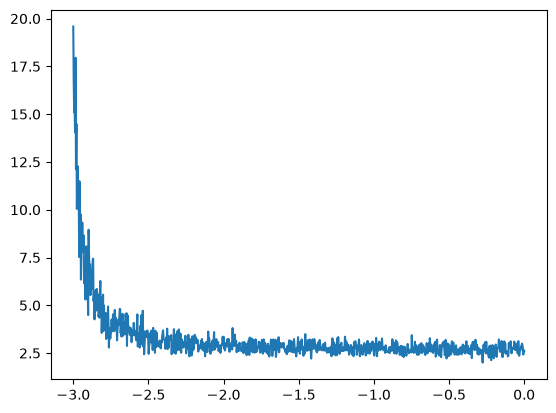

In [123]:
plt.plot(lri,lossi)

In [ ]:
lri = []
lossi = []
for i in range(10000):
    # minibatch
    ix = torch.randint(0,X.shape[0],(32,))
    # forward pass
    emb = C[X[ix]] #(32,3,20
    h = torch.tanh(emb.view(-1,6)@ W1 + b1)
    logits = h @ W2 + b2 
    # counts = logits.exp()
    # prob = counts / counts.sum(1,keepdims=True)
    # loss = -prob[torch.arange(32),Y].log().mean()
    loss = F.cross_entropy(logits,Y[ix])
    # print(loss.item())
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update 
    # lr = lrs[i]
    lr = 0.1
    for p in parameters:
        p.data += -0.1 * p.grad
    # track stat
    # lri.append(lre[i])
    # lossi.append(loss.item())
# print(loss.item())

In [125]:
emb = C[X[ix]] #(32,3,20
h = torch.tanh(emb.view(-1,6)@ W1 + b1)
logits = h @ W2 + b2 
loss = F.cross_entropy(logits,Y[ix])
loss

tensor(2.3283, grad_fn=<NllLossBackward0>)

In [126]:
# training split, dev/validation set, test split
# 80%,                10%,                10%


In [132]:
# build dataset 
def build_dataset(words):
    block_size = 3
    X,Y = [], []
    for w in words:
        #print(w)
        context = [0]*block_size
        for ch in w +".":
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print("".join(itos[i] for i in context),"----->",itos[ix])
            context = context[1:] + [ix] #crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape,Y.shape)
    return X,Y
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])



torch.Size([182441, 3]) torch.Size([182441])
torch.Size([22902, 3]) torch.Size([22902])
torch.Size([22803, 3]) torch.Size([22803])


In [141]:
Xtr.shape,Ytr.shape #dataset

(torch.Size([182441, 3]), torch.Size([182441]))

In [142]:
g = torch.Generator().manual_seed(2147483647) #for reproducibility
C = torch.randn((27,2),generator=g)
W1 = torch.randn((6,100),generator=g)
b1 = torch.randn(100,generator=g)
W2 = torch.randn((100,27),generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C,W1,b1,W2,b2]

In [143]:
sum(p.nelement() for p in parameters) #numbers of parameters in total

3481

In [144]:
for p in parameters:
    p.requires_grad = True

In [145]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre

In [135]:
lri = []
lossi = []
for i in range(30000):
    # minibatch
    ix = torch.randint(0,Xtr.shape[0],(32,))
    # forward pass
    emb = C[Xtr[ix]] #(32,3,20
    h = torch.tanh(emb.view(-1,6)@ W1 + b1)
    logits = h @ W2 + b2 
    # counts = logits.exp()
    # prob = counts / counts.sum(1,keepdims=True)
    # loss = -prob[torch.arange(32),Y].log().mean()
    loss = F.cross_entropy(logits,Ytr[ix])
    # print(loss.item())
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update 
    # lr = lrs[i]
    lr = 0.1
    for p in parameters:
        p.data += -0.1 * p.grad
    # track stat
    # lri.append(lre[i])
    # lossi.append(loss.item())
# print(loss.item())

In [136]:
print(loss.item())

2.344766139984131


In [138]:
emb = C[Xdev] #(32,3,20
h = torch.tanh(emb.view(-1,6)@ W1 + b1)
logits = h @ W2 + b2 
loss = F.cross_entropy(logits,Ydev)
loss

tensor(2.3775, grad_fn=<NllLossBackward0>)

In [139]:
emb = C[Xtr] #(32,3,20
h = torch.tanh(emb.view(-1,6)@ W1 + b1)
logits = h @ W2 + b2 
loss = F.cross_entropy(logits,Ytr)
loss

tensor(2.3715, grad_fn=<NllLossBackward0>)

In [146]:
g = torch.Generator().manual_seed(2147483647) #for reproducibility
C = torch.randn((27,2),generator=g)
W1 = torch.randn((6,300),generator=g)
b1 = torch.randn(300,generator=g)
W2 = torch.randn((300,27),generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C,W1,b1,W2,b2]

In [147]:
sum(p.nelement() for p in parameters) #numbers of parameters in total

10281

In [148]:
for p in parameters:
    p.requires_grad = True

In [167]:
lri = []
lossi = []
stepi = []
for i in range(30000):
    # minibatch
    ix = torch.randint(0,Xtr.shape[0],(32,))
    # forward pass
    emb = C[Xtr[ix]] #(32,3,20
    h = torch.tanh(emb.view(-1,6)@ W1 + b1)
    logits = h @ W2 + b2 
    # counts = logits.exp()
    # prob = counts / counts.sum(1,keepdims=True)
    # loss = -prob[torch.arange(32),Y].log().mean()
    loss = F.cross_entropy(logits,Ytr[ix])
    # print(loss.item())
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update 
    # lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -0.1 * p.grad
    # track stat
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.item())
# print(loss.item())

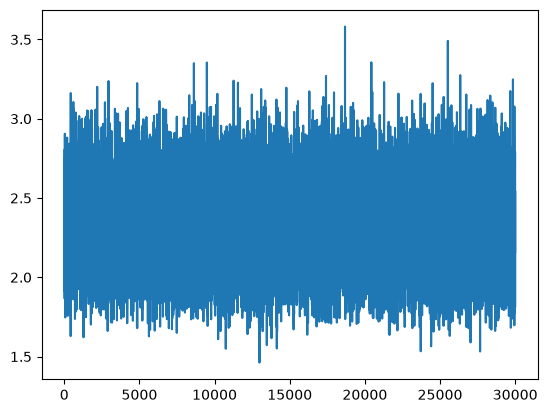

In [168]:
plt.plot(stepi,lossi)

In [169]:
emb = C[Xtr] #(32,3,20
h = torch.tanh(emb.view(-1,6)@ W1 + b1)
logits = h @ W2 + b2 
loss = F.cross_entropy(logits,Ytr)
loss

tensor(2.3478, grad_fn=<NllLossBackward0>)

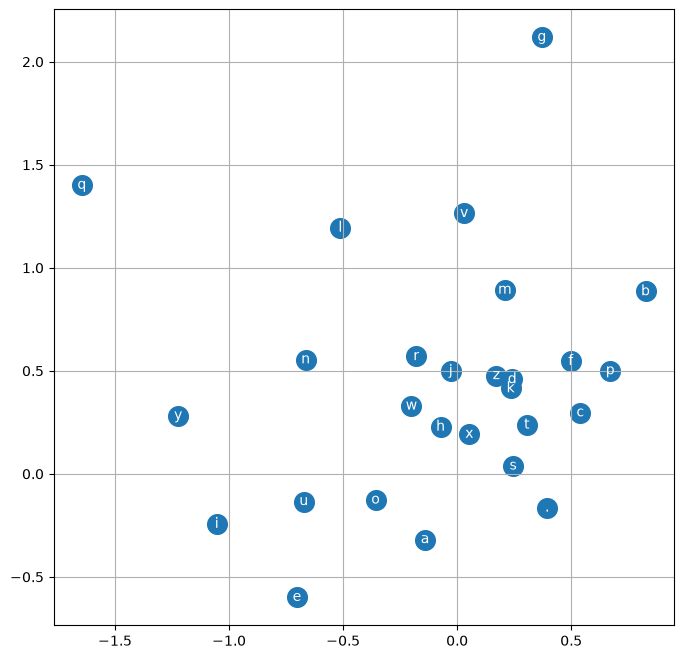

In [172]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data,C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(),C[i,1].item(),itos[i],ha="center",va="center",color="white")
plt.grid("minor")

In [173]:
g = torch.Generator().manual_seed(2147483647) #for reproducibility
C = torch.randn((27,10),generator=g)
W1 = torch.randn((30,200),generator=g)
b1 = torch.randn(200,generator=g)
W2 = torch.randn((200,27),generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C,W1,b1,W2,b2]

In [174]:
sum(p.nelement() for p in parameters) #numbers of parameters in total

11897

In [175]:
for p in parameters:
    p.requires_grad = True

In [177]:
lri = []
lossi = []
stepi = []

In [191]:

for i in range(50000):
    # minibatch
    ix = torch.randint(0,Xtr.shape[0],(32,))
    # forward pass
    emb = C[Xtr[ix]] #(32,3,20
    h = torch.tanh(emb.view(-1,30)@ W1 + b1)
    logits = h @ W2 + b2 
    # counts = logits.exp()
    # prob = counts / counts.sum(1,keepdims=True)
    # loss = -prob[torch.arange(32),Y].log().mean()
    loss = F.cross_entropy(logits,Ytr[ix])
    # print(loss.item())
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update 
    # lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -0.1 * p.grad
    # track stat
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())
# print(loss.item())

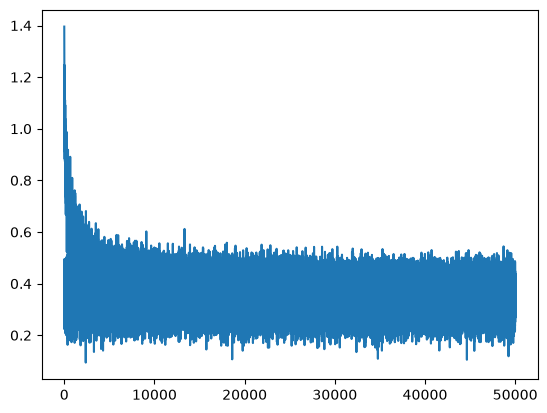

In [192]:
plt.plot(stepi,lossi)

In [193]:
emb = C[Xtr] #(32,3,20
h = torch.tanh(emb.view(-1,30)@ W1 + b1)
logits = h @ W2 + b2 
loss = F.cross_entropy(logits,Ytr)
loss

tensor(2.1799, grad_fn=<NllLossBackward0>)